# Magnitude MP-PCA Denoising

Gaussian noise가 추가된 multi-echo GRE complex 데이터를 magnitude로 변환한 뒤, DIPY의 MP-PCA를 적용하여 denoising을 수행한다.

10%, 30%, 50% noise 데이터에 동일한 조건의 MP-PCA를 적용하여 noise level에 따른 denoising 결과를 비교한다.

In [32]:
import numpy as np
import scipy.io as sio
from pathlib import Path
import matplotlib.pyplot as plt
from dipy.denoise.localpca import mppca

### 환경설정

In [13]:
NOISE_LEVELS = [10, 30, 50]
PATCH_R = 2

NOISY_DIR = Path("./data/noisy_data")
OUT_DIR = Path("./data/denoised/magnitude")

OUT_DIR.mkdir(parents=True, exist_ok=True)

### 1. Noise 데이터 불러오기

In [16]:
noisy_datasets = {}

for noise_level in NOISE_LEVELS:
    noisy_path = (
        NOISY_DIR /
        f"noisy_meas_gre_dir1_{noise_level}.mat"
    )

    noisy_data = sio.loadmat(
        noisy_path,
        simplify_cells=True
    )

    noisy_datasets[noise_level] = noisy_data

    print(
        f"{noise_level}% noise 데이터 불러오기 완료:",
        noisy_data["noisy_complex"].shape
    )

10% noise 데이터 불러오기 완료: (256, 224, 176, 6)
30% noise 데이터 불러오기 완료: (256, 224, 176, 6)
50% noise 데이터 불러오기 완료: (256, 224, 176, 6)


### 2. Magnitude 변환

In [21]:
magnitude_data = {}

for noise_level in NOISE_LEVELS:
    noisy_complex = noisy_datasets[noise_level]["noisy_complex"]

    noisy_mag = np.abs(
        noisy_complex
    ).astype(np.float32)

    magnitude_data[noise_level] = noisy_mag

    print(
        f"{noise_level}% magnitude 변환 완료:",
        noisy_mag.shape
    )

10% magnitude 변환 완료: (256, 224, 176, 6)
30% magnitude 변환 완료: (256, 224, 176, 6)
50% magnitude 변환 완료: (256, 224, 176, 6)


### 3. MP-PCA Denoising

In [23]:
denoised_data = {}

for noise_level in NOISE_LEVELS:
    noisy_mag = magnitude_data[noise_level]

    mask = noisy_datasets[noise_level][
        "mask_brain"
    ].astype(bool)

    print("\n" + "=" * 50)
    print(f"Noise level  : {noise_level}%")
    print(f"Patch radius : {PATCH_R}")
    print(
        f"Patch size   : "
        f"{2 * PATCH_R + 1} x "
        f"{2 * PATCH_R + 1} x "
        f"{2 * PATCH_R + 1}"
    )
    print("=" * 50)

    deno_mag = mppca(
        noisy_mag,
        mask=mask,
        patch_radius=PATCH_R
    )

    denoised_data[noise_level] = deno_mag

    print(f"{noise_level}% denoising 완료")


Noise level  : 10%
Patch radius : 2
Patch size   : 5 x 5 x 5


C:\Users\653wa\anaconda3\Lib\site-packages\dipy\denoise\localpca.py:377: RuntimeWarning: invalid value encountered in divide
  denoised_arr = thetax / theta


10% denoising 완료

Noise level  : 30%
Patch radius : 2
Patch size   : 5 x 5 x 5
30% denoising 완료

Noise level  : 50%
Patch radius : 2
Patch size   : 5 x 5 x 5
50% denoising 완료


### 4. 결과 저장

In [26]:
for noise_level in NOISE_LEVELS:
    noisy_data = noisy_datasets[noise_level]
    deno_mag = denoised_data[noise_level]

    output_path = ( 
        OUT_DIR /
        f"denoised_magnitude_{noise_level}_r{PATCH_R}.mat"
    )

    save_data = {
        "deno_mag": deno_mag,
        "mask_brain": noisy_data["mask_brain"],
        "noise_level": noise_level,
        "patch_radius": PATCH_R,
        "te_gre": noisy_data["te_gre"],
        "delta_TE": noisy_data["delta_TE"],
        "voxel_size_gre": noisy_data["voxel_size_gre"],
        "B0_dir": noisy_data["B0_dir"],
        "CF": noisy_data["CF"],
    }

    sio.savemat(
        output_path,
        save_data
    )

    print("저장 완료 →", output_path)

저장 완료 → data\denoised\magnitude\denoised_magnitude_10_r2.mat
저장 완료 → data\denoised\magnitude\denoised_magnitude_30_r2.mat
저장 완료 → data\denoised\magnitude\denoised_magnitude_50_r2.mat


### 5. 시각화

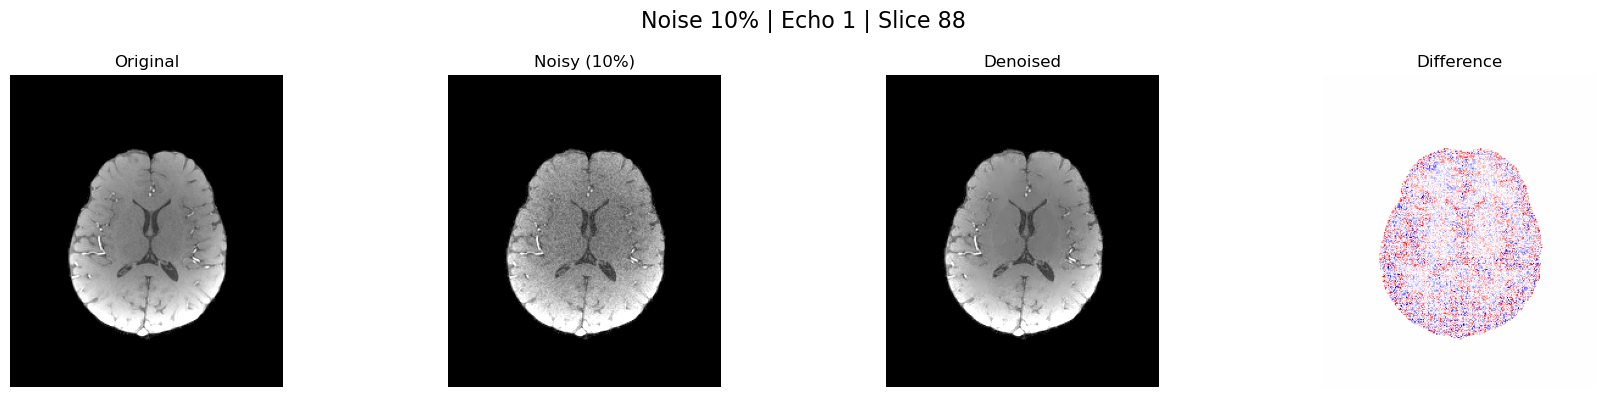

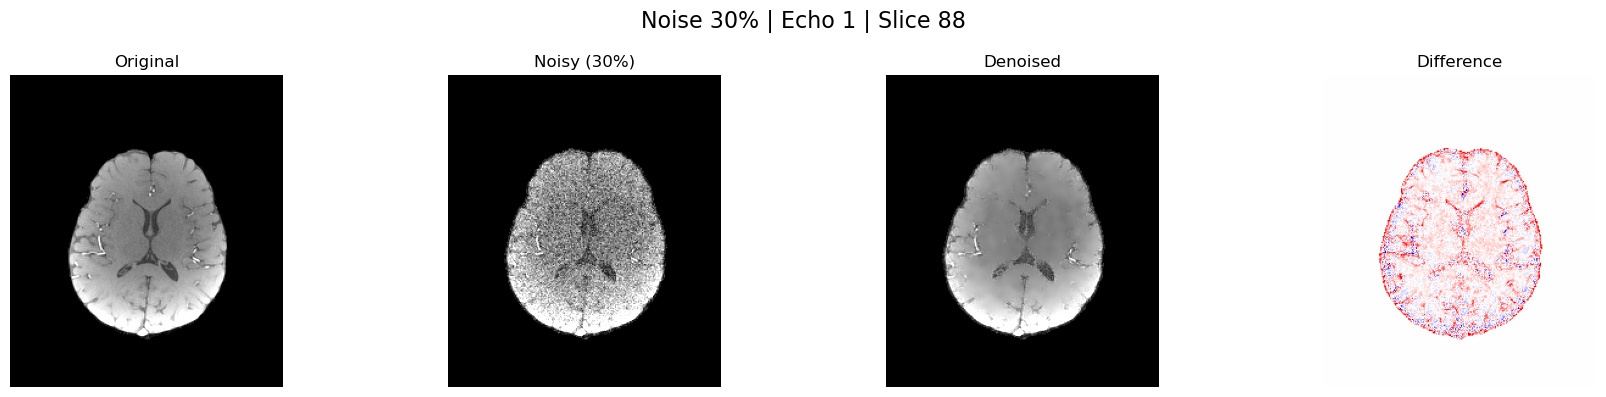

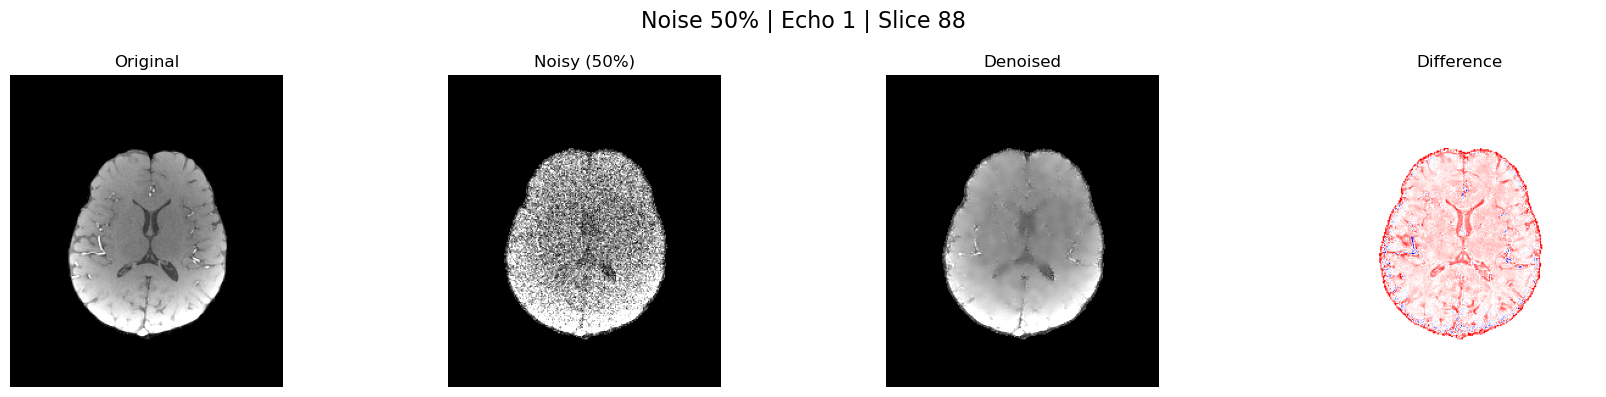

In [34]:
orig_data = sio.loadmat(
    "./data/meas_gre_dir1.mat",
    simplify_cells=True
)

orig_complex = orig_data["meas_gre"]
orig_mag = np.abs(orig_complex).astype(np.float32)

echo_idx = 0
slice_idx = 88

for noise_level in NOISE_LEVELS:
    noisy_mag = magnitude_data[noise_level]
    deno_mag = denoised_data[noise_level]
    mask = noisy_datasets[noise_level]["mask_brain"].astype(bool)

    orig_2d = orig_mag[:, :, slice_idx, echo_idx]
    noisy_2d = noisy_mag[:, :, slice_idx, echo_idx]
    deno_2d = deno_mag[:, :, slice_idx, echo_idx]
    mask_2d = mask[:, :, slice_idx]

    diff_2d = deno_2d - orig_2d

    vmin, vmax = np.percentile(
        orig_mag[mask],
        (1, 99)
    )

    dv = np.percentile(
        np.abs(diff_2d[mask_2d]),
        99
    )

    fig, ax = plt.subplots(1, 4, figsize=(18, 4))

    ax[0].imshow(
        orig_2d,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(
        noisy_2d,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    ax[1].set_title(f"Noisy ({noise_level}%)")
    ax[1].axis("off")

    ax[2].imshow(
        deno_2d,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    ax[2].set_title("Denoised")
    ax[2].axis("off")

    ax[3].imshow(
        diff_2d,
        cmap="bwr",
        vmin=-dv,
        vmax=dv
    )
    ax[3].set_title("Difference")
    ax[3].axis("off")

    fig.suptitle(
        f"Noise {noise_level}% | Echo {echo_idx + 1} | Slice {slice_idx}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()